In [11]:
# plot_ner.py
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Config ──────────────────────────────────────────────────────────────
CSV_PATH = "ner_results.csv"
LABELS = [
    "person", "norp", "facility", "organization", "gpe", "location",
    "product", "event", "work_of_art", "law", "language",
    "date", "time", "percent", "money", "quantity", "ordinal", "cardinal",
    "religion", "political_party", "nationality", "ethnic_group",
    "title", "award", "disease", "chemical", "weapon",
    "vehicle", "currency", "brand"
]

# ── Load Data ─────────────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)

# ── Entity Counts Table ───────────────────────────────────────────────────
label_counts = df['label'].value_counts().reindex(LABELS, fill_value=0)
label_counts_sorted = label_counts.sort_values(ascending=False)

score_stats = df.groupby('label')['score'].agg(['mean', 'median']).reindex(label_counts_sorted.index).fillna(0).round(3)

counts_table = pd.DataFrame({
    "Label": label_counts_sorted.index,
    "Count": label_counts_sorted.values,
    "Percentage": (label_counts_sorted.values / label_counts_sorted.values.sum() * 100).round(2),
    "Mean Score": score_stats['mean'].values,
    "Median Score": score_stats['median'].values
})



In [12]:
counts_table

,Label,Count,Percentage,Mean Score,Median Score
0,organization,2000559,23.54,0.752,0.789
1,person,1920645,22.60,0.796,0.859
2,location,1256266,14.78,0.753,0.786
3,date,444352,5.23,0.638,0.632
4,product,436506,5.14,0.670,0.664
5,event,343832,4.05,0.633,0.608
6,quantity,302790,3.56,0.547,0.524
7,time,264210,3.11,0.589,0.573
8,brand,213213,2.51,0.818,0.863
9,nationality,185272,2.18,0.723,0.740


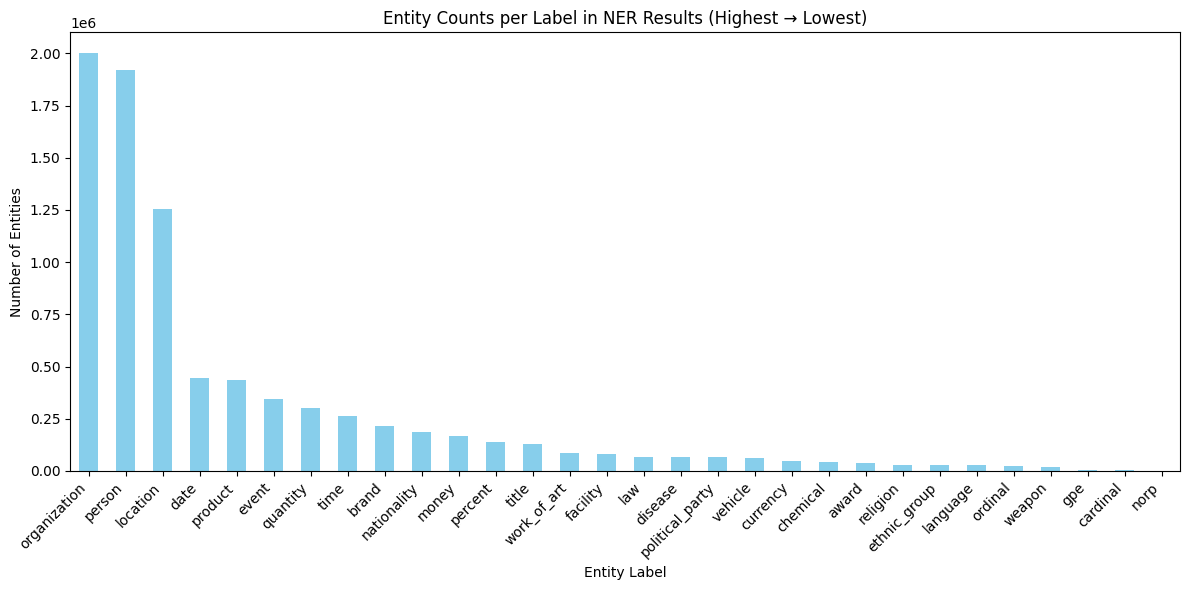

In [9]:
# ── Bar Plot: Entity Counts ───────────────────────────────────────────────
plt.figure(figsize=(12, 6))
label_counts_sorted.plot(kind='bar', color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Entity Label")
plt.ylabel("Number of Entities")
plt.title("Entity Counts per Label in NER Results (Highest → Lowest)")
plt.tight_layout()
plt.show()

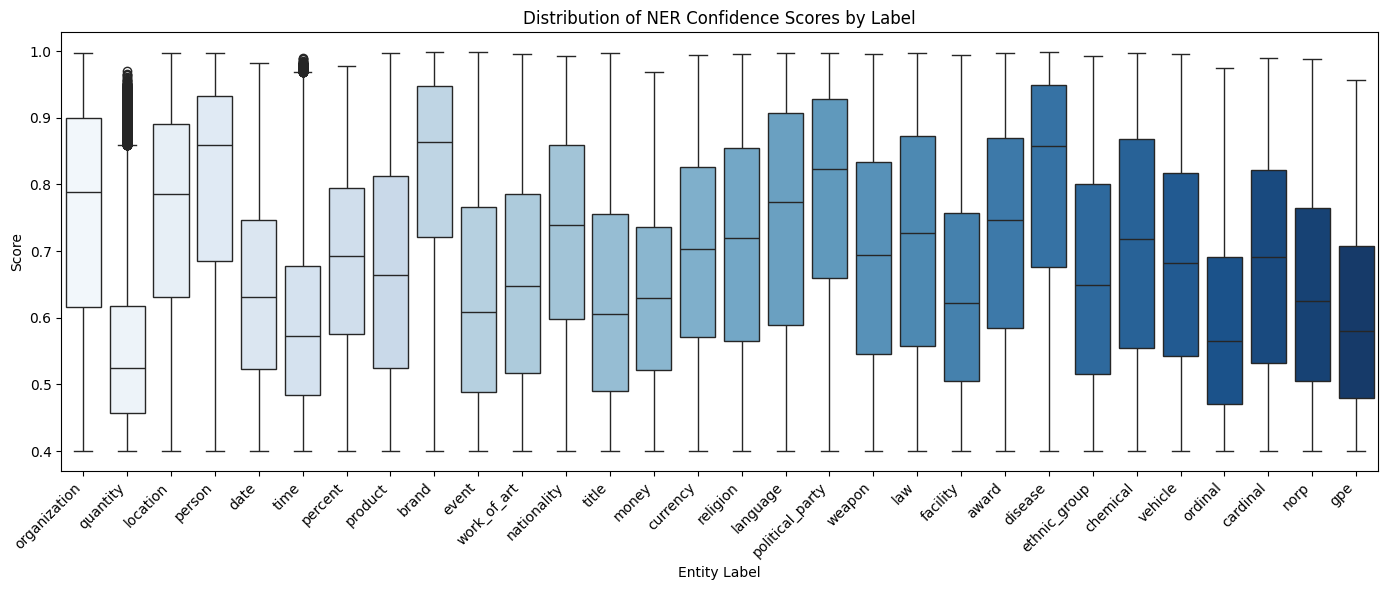

In [13]:
# ── Boxplot: Score Distribution ──────────────────────────────────────────
labels_in_data = df['label'].unique()

plt.figure(figsize=(14, 6))
sns.boxplot(x="label", y="score", data=df, order=labels_in_data, palette="Blues", hue="label", dodge=False, legend=False)
plt.xticks(rotation=45, ha='right')
plt.xlabel("Entity Label")
plt.ylabel("Score")
plt.title("Distribution of NER Confidence Scores by Label")
plt.tight_layout()
plt.show()

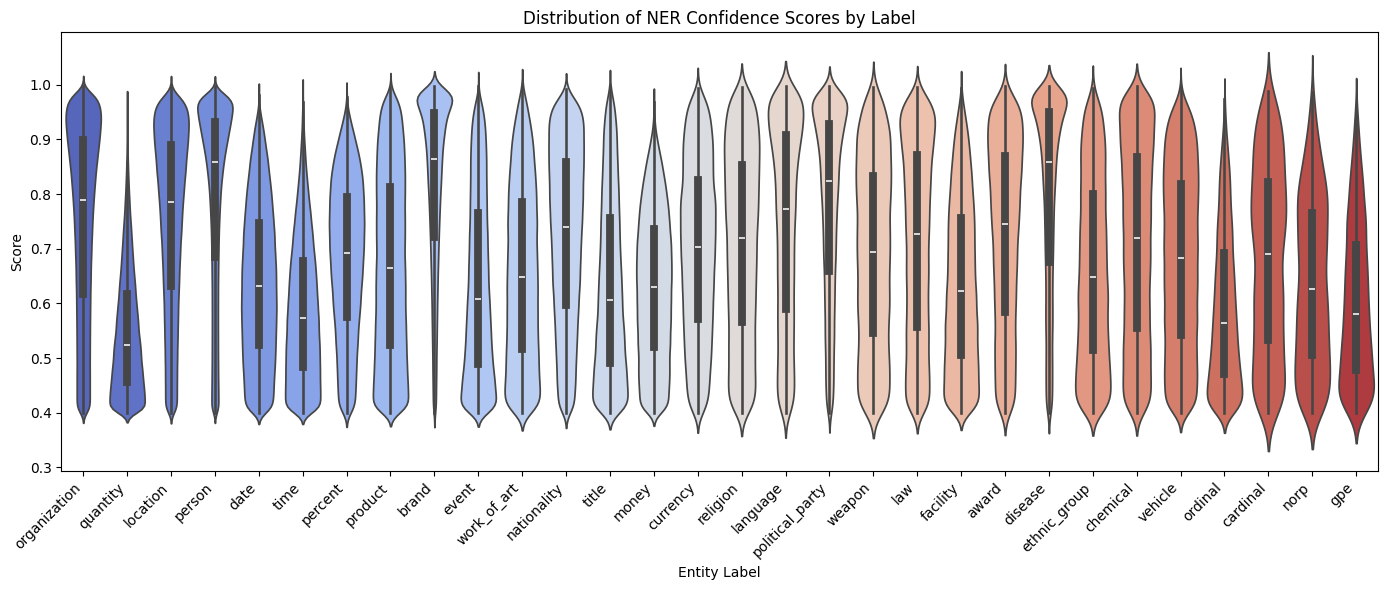

In [15]:
# ── Violin Plot: Score Distribution ──────────────────────────────────────
plt.figure(figsize=(14, 6))
sns.violinplot(
    x="label", 
    y="score", 
    data=df, 
    order=labels_in_data, 
    hue="label",          # map palette to each label
    dodge=False,          # don't separate violins by hue
    palette="coolwarm",
    legend=False
)
plt.xticks(rotation=45, ha='right')
plt.xlabel("Entity Label")
plt.ylabel("Score")
plt.title("Distribution of NER Confidence Scores by Label")
plt.tight_layout()
plt.show()